<a href="https://colab.research.google.com/github/amelianiisrina/NiisrinaAmelia_2411532009_ML2526/blob/main/Praktikum1/MultipleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
df = pd.DataFrame(data= housing.data, columns=housing.feature_names)
df['MedHouseValue'] = pd.Series(housing.target)

targets=df['MedHouseValue']
inputs = df.drop(['MedHouseValue'],axis=1)
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [4]:
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.3, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_test)

[[8.14678418e-02 4.70588235e-01 2.34243862e-02 ... 2.56319369e-03
  3.73404255e-01 5.31872510e-01]
 [1.40094619e-01 5.68627451e-01 2.94319155e-02 ... 1.59940545e-03
  2.75531915e-01 4.87051793e-01]
 [2.05528200e-01 1.00000000e+00 2.18994569e-02 ... 5.37584539e-04
  5.58510638e-01 1.90239044e-01]
 ...
 [2.07728169e-01 2.94117647e-01 2.03757930e-02 ... 1.34975225e-03
  1.19148936e-01 6.41434263e-01]
 [2.17245279e-01 1.76470588e-01 3.27130659e-02 ... 2.29769634e-03
  5.60638298e-01 3.05776892e-01]
 [1.76004469e-01 3.13725490e-01 1.74931855e-02 ... 1.54725775e-03
  1.70212766e-01 6.08565737e-01]]


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

Intercept: 3.6307047193242434
Slope: [  6.46451636   0.49377527 -17.21787732  19.70092818  -0.02767764
  -4.1877334   -3.93424542  -4.35422728]


In [8]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 0.5305677824766751
R2: 0.5957702326061665


/tmp/ipykernel_477/1137267832.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


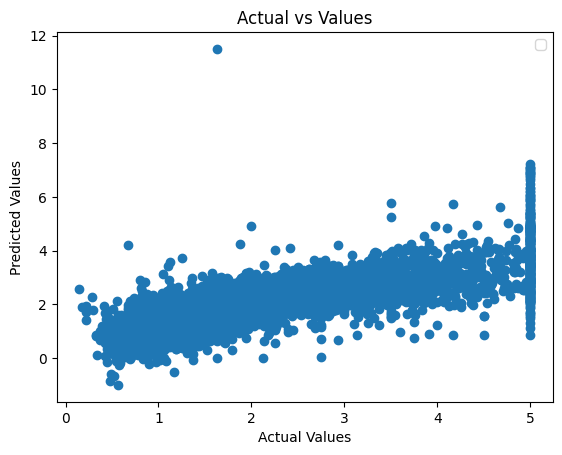

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Values")
plt.show()

In [17]:
import pickle

filename = 'finalized_model.sav'
pickle.dump(model, open(filename, 'wb'))